# 05 — Model Evaluation & Hyperparameter Tuning
**Project:** Predictive Analytics and AI-Driven Nutrition Solution for Early Detection and Management of Type 2 Diabetes

**Notebook:** 5 of 5

**Purpose:** Compare all three trained models side by side, tune each one using GridSearchCV, select the best tuned model, and save the final production-ready model.

**Input:** Trained models and test data from `04_model_development.ipynb` (via `models/` folder)

**Output:** `models/glucose_spike_model.pkl` — final best tuned model ready for deployment.

---

## 0. Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
plt.rcParams["figure.dpi"]   = 120
plt.rcParams["savefig.bbox"] = "tight"

SPIKE_COLORS = {0: "#4CAF50", 1: "#E53935"}
ACCENT       = "#2196F3"
RANDOM_STATE = 42

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from xgboost import XGBClassifier
import joblib, json

print("Libraries loaded.")

---
## 1. Load Models and Test Data from Notebook 4

In [ ]:
import numpy as np

# reload all three trained models
lr_model  = joblib.load("models/lr_model.pkl")
rf_model  = joblib.load("models/rf_model.pkl")
xgb_model = joblib.load("models/xgb_model.pkl")
scaler    = joblib.load("models/scaler.pkl")

# reload the test set — same split as notebook 4
feature_cols  = pd.read_csv("models/feature_columns.csv").iloc[:, 0].tolist()
X_test_scaled = pd.DataFrame(np.load("models/X_test_scaled.npy"), columns=feature_cols)
y_test        = pd.Series(np.load("models/y_test.npy"))
X_train_resampled = np.load("models/X_train_resampled.npy")
y_train_resampled = np.load("models/y_train_resampled.npy")

# reload untuned metrics for before/after comparison
with open("models/untuned_metrics.json") as f:
    untuned = json.load(f)

# generate predictions from the loaded models
lr_pred       = lr_model.predict(X_test_scaled)
lr_pred_prob  = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_pred       = rf_model.predict(X_test_scaled)
rf_pred_prob  = rf_model.predict_proba(X_test_scaled)[:, 1]
xgb_pred      = xgb_model.predict(X_test_scaled)
xgb_pred_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

lr_metrics  = untuned["Logistic Regression"]
rf_metrics  = untuned["Random Forest"]
xgb_metrics = untuned["XGBoost"]

print("All models and test data loaded successfully.")

## 15. Model Evaluation & Comparison

In [46]:
results = {
    "Logistic Regression": lr_metrics,
    "Random Forest"      : rf_metrics,
    "XGBoost"            : xgb_metrics,
}

comparison_df = pd.DataFrame(results).T
print("Model Comparison:")
print(comparison_df.round(4).to_string())

Model Comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.770     0.7316  0.7948    0.7619   0.8557
Random Forest           0.765     0.7317  0.7775    0.7539   0.8379
XGBoost                 0.760     0.7290  0.7667    0.7474   0.8386


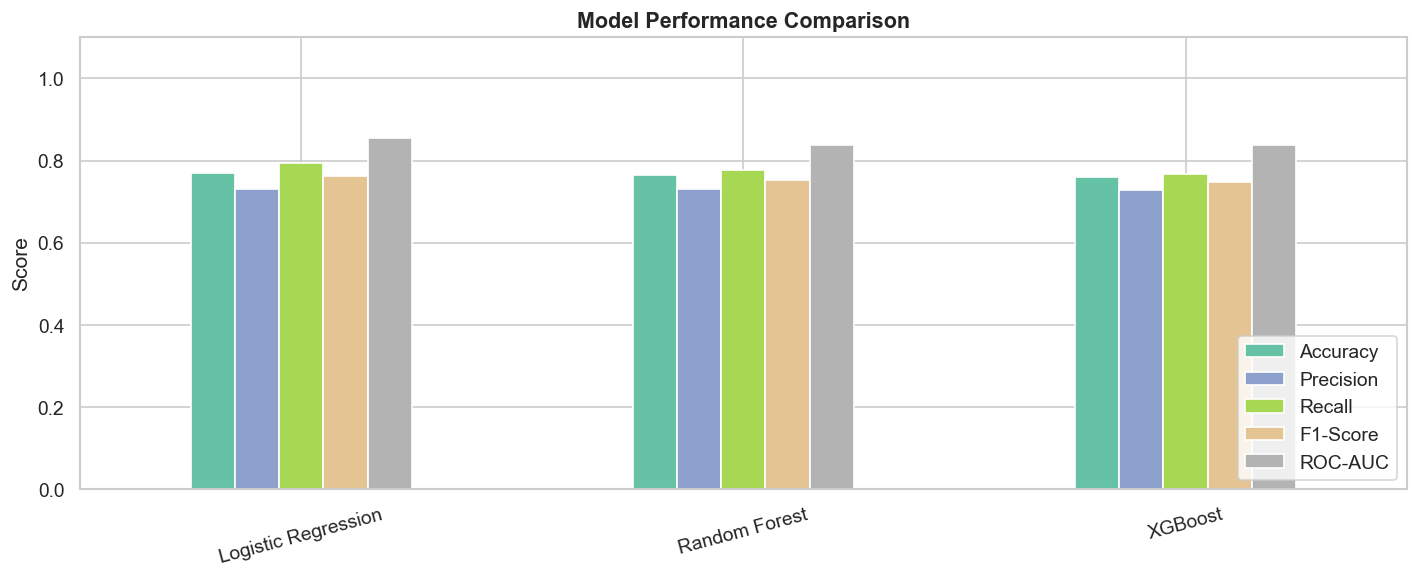

In [47]:
fig, ax = plt.subplots(figsize=(12, 5))
comparison_df.plot(kind="bar", ax=ax, edgecolor="white", colormap="Set2")
ax.set_title("Model Performance Comparison", fontsize=13, fontweight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.set_xticklabels(comparison_df.index, rotation=15)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 16. ROC Curve Analysis for All Models

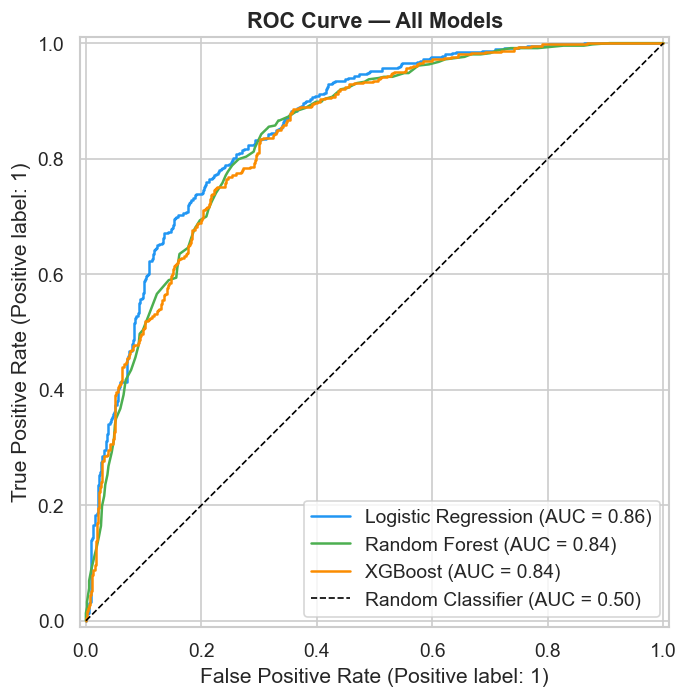

In [48]:
# plotting all three together makes it easy to compare discriminative ability
# the closer the curve hugs the top-left corner, the better
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(y_test, lr_pred_prob,  ax=ax, name="Logistic Regression", color="#2196F3")
RocCurveDisplay.from_predictions(y_test, rf_pred_prob,  ax=ax, name="Random Forest",       color="#4CAF50")
RocCurveDisplay.from_predictions(y_test, xgb_pred_prob, ax=ax, name="XGBoost",             color="#FB8C00")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier (AUC = 0.50)")
ax.set_title("ROC Curve — All Models", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 17. Hyperparameter Tuning for All Models

In [49]:
CV      = 5         # 5-fold cross-validation is a good balance of reliability vs speed
SCORING = "roc_auc" # optimise for AUC since it is our primary clinical metric

tuned_results = {}
tuned_models  = {}

In [50]:
print("=" * 55)
print("  Tuning Logistic Regression ...")
print("=" * 55)

lr_param_grid = {
    'C'      : [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'solver' : ['saga', 'lbfgs'],
    'penalty': ['l1', 'l2'],
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced',
                       random_state=RANDOM_STATE),
    lr_param_grid,
    cv=CV, scoring=SCORING, n_jobs=-1, verbose=0
)
lr_grid.fit(X_train_resampled, y_train_resampled)

print(f"  Best params  : {lr_grid.best_params_}")
print(f"  Best ROC-AUC : {lr_grid.best_score_:.4f}")

tuned_models['Logistic Regression'] = lr_grid.best_estimator_

  Tuning Logistic Regression ...
  Best params  : {'C': 0.01, 'penalty': 'l2', 'solver': 'saga'}
  Best ROC-AUC : 0.8509


In [51]:
print("=" * 55)
print("  Tuning Random Forest ...")
print("=" * 55)

rf_param_grid = {
    "n_estimators"     : [100, 200, 300],
    "max_depth"        : [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_grid, cv=CV, scoring=SCORING, n_jobs=-1, verbose=0
)
rf_grid.fit(X_train_resampled, y_train_resampled)

print(f"  Best params  : {rf_grid.best_params_}")
print(f"  Best ROC-AUC : {rf_grid.best_score_:.4f}")
tuned_models["Random Forest"] = rf_grid.best_estimator_

  Tuning Random Forest ...
  Best params  : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
  Best ROC-AUC : 0.8556


In [52]:
print("=" * 55)
print("  Tuning XGBoost ...")
print("=" * 55)

xgb_param_grid = {
    "n_estimators"    : [100, 200, 300],
    "max_depth"       : [3, 6, 9],
    "learning_rate"   : [0.01, 0.1, 0.2],
    "subsample"       : [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss"),
    xgb_param_grid, cv=CV, scoring=SCORING, n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train_resampled, y_train_resampled)

print(f"  Best params  : {xgb_grid.best_params_}")
print(f"  Best ROC-AUC : {xgb_grid.best_score_:.4f}")
tuned_models["XGBoost"] = xgb_grid.best_estimator_

  Tuning XGBoost ...
  Best params  : {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 9, 'n_estimators': 300, 'subsample': 0.7}
  Best ROC-AUC : 0.8530


In [53]:
# evaluate every tuned model on the held-out test set
print("\nEvaluating all tuned models on test set...")

for name, model in tuned_models.items():
    pred      = model.predict(X_test_scaled)
    pred_prob = model.predict_proba(X_test_scaled)[:, 1]
    tuned_results[name] = {
        "Accuracy" : accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall"   : recall_score(y_test, pred, zero_division=0),
        "F1-Score" : f1_score(y_test, pred, zero_division=0),
        "ROC-AUC"  : roc_auc_score(y_test, pred_prob)
    }

tuned_df = pd.DataFrame(tuned_results).T
print("\nTuned Model Comparison:")
print(tuned_df.round(4).to_string())


Evaluating all tuned models on test set...

Tuned Model Comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.770     0.7335  0.7905    0.7609   0.8574
Random Forest           0.760     0.7234  0.7797    0.7505   0.8419
XGBoost                 0.765     0.7235  0.7970    0.7585   0.8471


BEFORE Tuning:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.770     0.7316  0.7948    0.7619   0.8557
Random Forest           0.765     0.7317  0.7775    0.7539   0.8379
XGBoost                 0.760     0.7290  0.7667    0.7474   0.8386

AFTER Tuning:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.770     0.7335  0.7905    0.7609   0.8574
Random Forest           0.760     0.7234  0.7797    0.7505   0.8419
XGBoost                 0.765     0.7235  0.7970    0.7585   0.8471


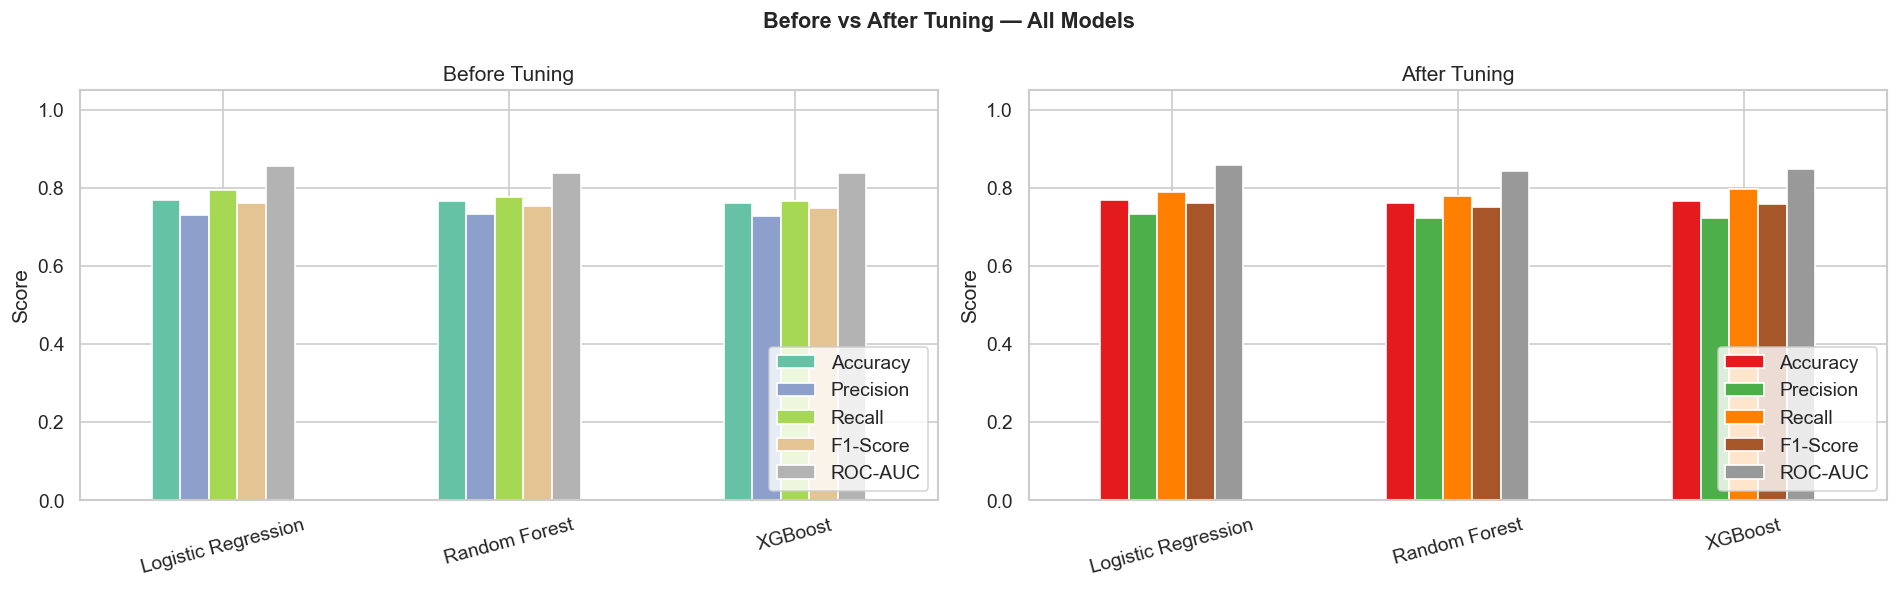

In [54]:
# side-by-side comparison shows exactly how much tuning helped each model
before_df = pd.DataFrame({
    "Logistic Regression": lr_metrics,
    "Random Forest"      : rf_metrics,
    "XGBoost"            : xgb_metrics,
}).T

print("BEFORE Tuning:")
print(before_df.round(4).to_string())
print("\nAFTER Tuning:")
print(tuned_df.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Before vs After Tuning — All Models", fontsize=13, fontweight="bold")

before_df.plot(kind="bar", ax=axes[0], edgecolor="white", colormap="Set2", ylim=(0, 1.05))
axes[0].set_title("Before Tuning")
axes[0].set_ylabel("Score")
axes[0].set_xticklabels(before_df.index, rotation=15)
axes[0].legend(loc="lower right")

tuned_df.plot(kind="bar", ax=axes[1], edgecolor="white", colormap="Set1", ylim=(0, 1.05))
axes[1].set_title("After Tuning")
axes[1].set_ylabel("Score")
axes[1].set_xticklabels(tuned_df.index, rotation=15)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [55]:
# let the numbers decide, pick whichever model scored highest on AUC
best_model_name = tuned_df["ROC-AUC"].idxmax()
best_model      = tuned_models[best_model_name]
best_roc_auc    = tuned_df.loc[best_model_name, "ROC-AUC"]

print("\n" + "=" * 52)
print("  BEST MODEL SELECTED")
print("=" * 52)
print(f"  Model   : {best_model_name}")
print(f"  ROC-AUC : {best_roc_auc:.4f}")
print("=" * 52)


  BEST MODEL SELECTED
  Model   : Logistic Regression
  ROC-AUC : 0.8574


Classification Report — Logistic Regression:
              precision    recall  f1-score   support

    No Spike       0.81      0.75      0.78       537
       Spike       0.73      0.79      0.76       463

    accuracy                           0.77      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.77      0.77      1000



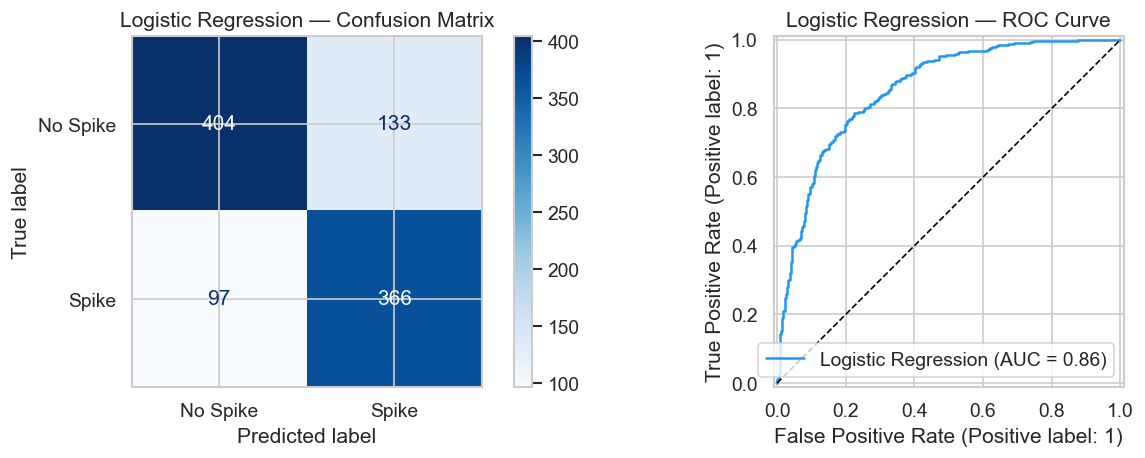

In [56]:
best_pred      = best_model.predict(X_test_scaled)
best_pred_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"Classification Report — {best_model_name}:")
print(classification_report(y_test, best_pred, target_names=["No Spike", "Spike"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred, ax=axes[0],
    display_labels=["No Spike", "Spike"], cmap="Blues")
axes[0].set_title(f"{best_model_name} — Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test, best_pred_prob, ax=axes[1],
    name=best_model_name, color="#2196F3")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set_title(f"{best_model_name} — ROC Curve")

plt.tight_layout()
plt.show()

In [57]:
import joblib, os
os.makedirs("models", exist_ok=True)

# save both the best tuned model and the scaler
# you need the scaler whenever you process new patient data before prediction
joblib.dump(best_model, "models/glucose_spike_model.pkl")
joblib.dump(scaler,     "models/glucose_spike_scaler.pkl")

print(f"Final model saved  : models/glucose_spike_model.pkl  ({best_model_name})")
print(f"Scaler saved       : models/glucose_spike_scaler.pkl")
print(f"Best ROC-AUC       : {best_roc_auc:.4f}")

Saved: glucose_spike_model.pkl  (Logistic Regression)
Saved: glucose_spike_scaler.pkl
